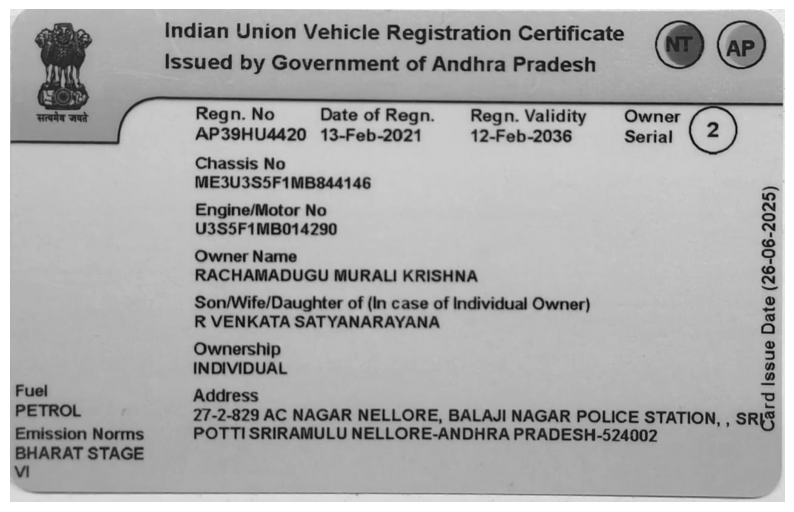

In [13]:
import cv2
from matplotlib import pyplot as plt
img = cv2.imread(r"C:/Users/niteshk/Downloads/Vehicle_RC/RC_Back.jpeg")
# img = cv2.imread(r'c:/Users/niteshk/Desktop/first_frames/first_frame.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Display inline using matplotlib (works when OpenCV GUI is not available)
plt.figure(figsize=(10,8))
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()


In [14]:
import pytesseract
pytesseract.pytesseract.tesseract_cmd = r"C:/Program Files/Tesseract-OCR/tesseract.exe"

In [15]:
import pytesseract
from PIL import Image

img = Image.open('C:/Users/niteshk/Downloads/Vehicle_RC/RC_Back.jpeg')
# img = Image.open('c:/Users/niteshk/Desktop/first_frames/first_frame.jpg')
text = pytesseract.image_to_string(img)
print(text)

Indian Union Vehicle Registration Certificate (x) (ar)
Issued by Government of Andhra Pradesh

Regn. No Date of Regn. Regn. Validity Owner
AP39HU4420 13-Feb-2021 12-Feb-2036 Serial
Chassis No

ME3U3S5F1MB844146

Engine/Motor No

U3S5F1MB014290

Owner Name

RACHAMADUGU MURALI KRISHNA

Son/Wife/Daughter of (In case of Individual Owner)
R VENKATA SATYANARAYANA

Card Issue Date (26-06-2025)

Ownership

INDIVIDUAL
Fuel Address
PETROL 27-2-829 AC NAGAR NELLORE, BALAJI NAGAR POLICE STATION, , SR
Emission Norms POTTISRIRAMULU NELLORE-ANDHRA PRADESH-524002

BHARAT STAGE
vi




In [16]:
%pip install PyYAML==6.0.2

Note: you may need to restart the kernel to use updated packages.


In [17]:
import easyocr

reader = easyocr.Reader(['en'])
results = reader.readtext('C:/Users/niteshk/Downloads/Vehicle_RC/RC_Back.jpeg')
print(results)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
c:\Users\niteshk\anaconda3\envs\myenv1\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\niteshk\anaconda3\envs\myenv1\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[([[np.int32(249), np.int32(14)], [np.int32(1022), np.int32(14)], [np.int32(1022), np.int32(64)], [np.int32(249), np.int32(64)]], 'Indian Union Vehicle Registration Certificate', np.float64(0.816961185796181)), ([[np.int32(1079), np.int32(41)], [np.int32(1131), np.int32(41)], [np.int32(1131), np.int32(77)], [np.int32(1079), np.int32(77)]], 'NT', np.float64(0.3321787238303715)), ([[np.int32(1179), np.int32(45)], [np.int32(1235), np.int32(45)], [np.int32(1235), np.int32(83)], [np.int32(1179), np.int32(83)]], 'AP', np.float64(0.9984798489325267)), ([[np.int32(250), np.int32(68)], [np.int32(973), np.int32(68)], [np.int32(973), np.int32(113)], [np.int32(250), np.int32(113)]], 'Issued by Government of Andhra Pradesh', np.float64(0.9492704767271651)), ([[np.int32(40), np.int32(166)], [np.int32(132), np.int32(166)], [np.int32(132), np.int32(190)], [np.int32(40), np.int32(190)]], 'Hrttt 7tud', np.float64(0.0028855797972482874)), ([[np.int32(301), np.int32(155)], [np.int32(443), np.int32(155)], 

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
c:\Users\niteshk\anaconda3\envs\myenv1\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


✅ OCR results saved to: C:\Users\niteshk\Downloads\extracted_text.csv


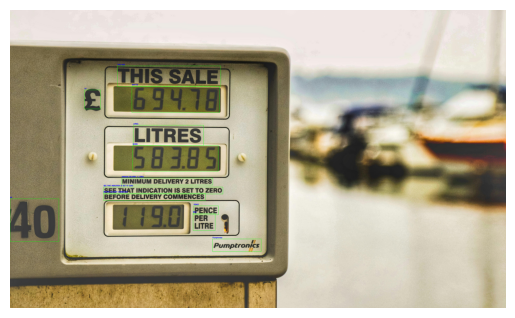

✅ Annotated image saved to: C:\Users\niteshk\Downloads\detected.jpg


In [2]:
import easyocr
import cv2
import csv
from matplotlib import pyplot as plt

# 1️⃣ Path to your image
image_path = r"c:\Users\niteshk\Downloads\reader.jpg"

# 2️⃣ Initialize EasyOCR reader
reader = easyocr.Reader(['en'])

# 3️⃣ Perform OCR
results = reader.readtext(image_path)

# 4️⃣ Load image
image = cv2.imread(image_path)

# 5️⃣ CSV file path
csv_output_path = r"C:\Users\niteshk\Downloads\extracted_text.csv"

# 6️⃣ Save extracted data to CSV
with open(csv_output_path, mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(["Text", "Confidence", "Top_Left_X", "Top_Left_Y", "Bottom_Right_X", "Bottom_Right_Y"])
    for (bbox, text, confidence) in results:
        top_left = bbox[0]
        bottom_right = bbox[2]
        writer.writerow([text, f"{confidence:.2f}", top_left[0], top_left[1], bottom_right[0], bottom_right[1]])

print(f"✅ OCR results saved to: {csv_output_path}")

# 7️⃣ Draw bounding boxes
for (bbox, text, confidence) in results:
    top_left = tuple(map(int, bbox[0]))
    bottom_right = tuple(map(int, bbox[2]))
    cv2.rectangle(image, top_left, bottom_right, (0, 255, 0), 2)
    cv2.putText(image, text, (top_left[0], top_left[1] - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

# 8️⃣ Display image (for Jupyter/VS Code)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# 9️⃣ Save annotated image
output_image_path = r"C:\Users\niteshk\Downloads\detected.jpg"
cv2.imwrite(output_image_path, image)
print(f"✅ Annotated image saved to: {output_image_path}")


In [29]:
import cv2
import pytesseract
import numpy as np
import pandas as pd
import os

# ==========================
# CONFIGURATION
# ==========================
image_path = r"c:\Users\niteshk\Desktop\last_frames\last_frame.jpg"  # your input image
output_dir = r"c:\Users\niteshk\Desktop\last_frames\output_results"
os.makedirs(output_dir, exist_ok=True)

east_model_path = r"c:\Users\niteshk\Downloads\frozen_east_text_detection.pb"  # Download if not available
csv_output_path = os.path.join(output_dir, "detected_text_results.csv")

# ==========================
# LOAD IMAGE
# ==========================
image = cv2.imread(image_path)
orig = image.copy()
(H, W) = image.shape[:2]

# EAST model expects multiples of 32
newW, newH = (320, 320)
rW = W / float(newW)
rH = H / float(newH)
image = cv2.resize(image, (newW, newH))
(H, W) = image.shape[:2]

# ==========================
# LOAD EAST MODEL
# ==========================
print("[INFO] Loading EAST text detector...")
net = cv2.dnn.readNet(east_model_path)

# define two output layer names for the EAST detector
layerNames = [
    "feature_fusion/Conv_7/Sigmoid",
    "feature_fusion/concat_3"
]

# ==========================
# DETECT TEXT REGIONS
# ==========================
blob = cv2.dnn.blobFromImage(image, 1.0, (W, H),
                             (123.68, 116.78, 103.94), swapRB=True, crop=False)
net.setInput(blob)
(scores, geometry) = net.forward(layerNames)

# ==========================
# DECODE PREDICTIONS
# ==========================
def decode_predictions(scores, geometry, conf_threshold=0.5):
    (numRows, numCols) = scores.shape[2:4]
    rects = []
    confidences = []

    for y in range(0, numRows):
        scoresData = scores[0, 0, y]
        xData0 = geometry[0, 0, y]
        xData1 = geometry[0, 1, y]
        xData2 = geometry[0, 2, y]
        xData3 = geometry[0, 3, y]
        anglesData = geometry[0, 4, y]

        for x in range(0, numCols):
            if scoresData[x] < conf_threshold:
                continue

            offsetX = x * 4.0
            offsetY = y * 4.0
            angle = anglesData[x]
            cos = np.cos(angle)
            sin = np.sin(angle)

            h = xData0[x] + xData2[x]
            w = xData1[x] + xData3[x]

            endX = int(offsetX + (cos * xData1[x]) + (sin * xData2[x]))
            endY = int(offsetY - (sin * xData1[x]) + (cos * xData2[x]))
            startX = int(endX - w)
            startY = int(endY - h)

            rects.append((startX, startY, endX, endY))
            confidences.append(scoresData[x])

    return (rects, confidences)

(rects, confidences) = decode_predictions(scores, geometry)
indices = cv2.dnn.NMSBoxesRotated(
    [cv2.RotatedRect(((r[0]+r[2])//2, (r[1]+r[3])//2), (r[2]-r[0], r[3]-r[1]), 0) for r in rects],
    confidences, 0.5, 0.4
)

# ==========================
# OCR & SAVE RESULTS
# ==========================
custom_config = r'--oem 3 --psm 6 -c tessedit_char_whitelist=0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz.,:-'
results = []

for i, rect in enumerate(rects):
    startX, startY, endX, endY = rect

    # Scale back to original image size
    startX = int(startX * rW)
    startY = int(startY * rH)
    endX = int(endX * rW)
    endY = int(endY * rH)

    # Ensure ROI is inside bounds
    startX, startY = max(0, startX), max(0, startY)
    endX, endY = min(orig.shape[1], endX), min(orig.shape[0], endY)
    if startX >= endX or startY >= endY:
        continue

    roi = orig[startY:endY, startX:endX]

    # Convert to grayscale + threshold
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    gray = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

    # OCR
    text = pytesseract.image_to_string(gray, config=custom_config).strip()

    if text:
        results.append({"Text": text, "Confidence": round(confidences[i], 3)})

        # Draw boxes on image
        cv2.rectangle(orig, (startX, startY), (endX, endY), (0, 255, 0), 2)
        cv2.putText(orig, text, (startX, startY - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

# ==========================
# SAVE OUTPUT
# ==========================
output_image_path = os.path.join(output_dir, "detected_output.jpg")
cv2.imwrite(output_image_path, orig)
print(f"[INFO] Output image saved to: {output_image_path}")

# Save results to CSV
df = pd.DataFrame(results)
df.to_csv(csv_output_path, index=False)
print(f"[INFO] Detected text saved to CSV: {csv_output_path}")

print("\n[DETECTED TEXT]")
print(df)


[INFO] Loading EAST text detector...
[INFO] Output image saved to: c:\Users\niteshk\Desktop\last_frames\output_results\detected_output.jpg
[INFO] Detected text saved to CSV: c:\Users\niteshk\Desktop\last_frames\output_results\detected_text_results.csv

[DETECTED TEXT]
              Text  Confidence
0            ogagg       0.998
1            oeagg       0.999
2            copay       0.997
3            Seagg       0.994
4              mis       0.998
5              mis       1.000
6             Sale       0.999
7             Sale       1.000
8             Sale       1.000
9             Sale       0.994
10            ofan       1.000
11           conng       1.000
12   Annan\nSAaagl       1.000
13       Anan\nsai       1.000
14     Anan\nSAggl       0.643
15             Mis       1.000
16             mis       1.000
17            nisi       0.993
18          Salell       0.999
19           Salel       0.998
20  x Annn\nULLuUu       1.000
21           Anann       1.000
22           Anann

In [ ]:
### WORKING CODE FOR PETROL PUMP OCR AND DATA EXTRACTION ###

import cv2
import easyocr
import numpy as np
import pandas as pd
from imutils.object_detection import non_max_suppression

# ======================
# CONFIGURATION
# ======================
EAST_MODEL_PATH = r"c:\Users\niteshk\Downloads\frozen_east_text_detection.pb"  # Path to EAST .pb file
IMAGE_PATH = r"c:\Users\niteshk\Desktop\last_frames\last_frame.jpg"                       # Input petrol pump image
OUTPUT_IMAGE = r"c:\Users\niteshk\Desktop\last_frames\annotated_output.jpg"
OUTPUT_CSV = r"c:\Users\niteshk\Desktop\last_frames\detected_petrol_readings.csv"

# ======================
# LOAD MODELS
# ======================
print("[INFO] Initializing EasyOCR and EAST models...")
reader = easyocr.Reader(['en'], gpu=False)
net = cv2.dnn.readNet(EAST_MODEL_PATH)

# ======================
# DETECT TEXT REGIONS
# ======================
def detect_text_regions(image):
    orig = image.copy()
    (H, W) = image.shape[:2]
    newW, newH = (320, 320)
    rW, rH = W / float(newW), H / float(newH)
    image = cv2.resize(image, (newW, newH))
    (H, W) = image.shape[:2]

    blob = cv2.dnn.blobFromImage(image, 1.0, (W, H),(123.68, 116.78, 103.94), swapRB=True, crop=False)
    net.setInput(blob)
    (scores, geometry) = net.forward(["feature_fusion/Conv_7/Sigmoid","feature_fusion/concat_3"])

    rects = []
    confidences = []

    (numRows, numCols) = scores.shape[2:4]
    for y in range(numRows):
        scoresData = scores[0, 0, y]
        xData0 = geometry[0, 0, y]
        xData1 = geometry[0, 1, y]
        xData2 = geometry[0, 2, y]
        xData3 = geometry[0, 3, y]
        anglesData = geometry[0, 4, y]

        for x in range(numCols):
            if scoresData[x] < 0.5:
                continue
            offsetX, offsetY = (x * 4.0, y * 4.0)
            angle = anglesData[x]
            cos = np.cos(angle)
            sin = np.sin(angle)
            h = xData0[x] + xData2[x]
            w = xData1[x] + xData3[x]
            endX = int(offsetX + (cos * xData1[x]) + (sin * xData2[x]))
            endY = int(offsetY - (sin * xData1[x]) + (cos * xData2[x]))
            startX = int(endX - w)
            startY = int(endY - h)
            rects.append((startX, startY, endX, endY))
            confidences.append(float(scoresData[x]))

    boxes = non_max_suppression(np.array(rects), probs=confidences)
    results = []
    for (startX, startY, endX, endY) in boxes:
        startX = int(startX * rW)
        startY = int(startY * rH)
        endX = int(endX * rW)
        endY = int(endY * rH)
        results.append((startX, startY, endX, endY))
    return results

# ======================
# EASYOCR TEXT RECOGNITION
# ======================
def extract_text(image, boxes):
    detected_texts = []
    for (startX, startY, endX, endY) in boxes:
        roi = image[startY:endY, startX:endX]
        if roi.size == 0:
            continue
        text_results = reader.readtext(roi)
        for (_, text, conf) in text_results:
            detected_texts.append((text.strip(), conf, (startX, startY, endX, endY)))
    return detected_texts

# ======================
# MAIN PIPELINE
# ======================
print("[INFO] Reading image...")
image = cv2.imread(IMAGE_PATH)
boxes = detect_text_regions(image)
detections = extract_text(image, boxes)

# ======================
# DATA MAPPING
# ======================
this_sale_value = None
liters_value = None

for text, conf, (x1, y1, x2, y2) in detections:
    lower = text.lower()
    if "this" in lower or "sale" in lower:
        this_sale_value = ""
    elif "liter" in lower:
        liters_value = ""
    elif any(c.isdigit() for c in text):
        # Numeric value detection: associate with nearest label
        if this_sale_value == "":
            this_sale_value = text
        elif liters_value == "":
            liters_value = text

# ======================
# SAVE RESULTS TO CSV
# ======================
data = {
    "This Sale": [this_sale_value if this_sale_value else ""],
    "Liters": [liters_value if liters_value else ""]
}
df = pd.DataFrame(data)
df.to_csv(OUTPUT_CSV, index=False)
print(f"[INFO] CSV saved as: {OUTPUT_CSV}")

# ======================
# DRAW AND SAVE IMAGE
# ======================
for text, conf, (x1, y1, x2, y2) in detections:
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(image, text, (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
cv2.imwrite(OUTPUT_IMAGE, image)
print(f"[INFO] Annotated image saved as: {OUTPUT_IMAGE}")
print("[INFO] Task complete ✅")


Using CPU. Note: This module is much faster with a GPU.


[INFO] Initializing EasyOCR and EAST models...
[INFO] Reading image...
[INFO] Reading image...


c:\Users\niteshk\anaconda3\envs\myenv1\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[INFO] CSV saved as: c:\Users\niteshk\Desktop\last_frames\detected_petrol_readings.csv
[INFO] Annotated image saved as: c:\Users\niteshk\Desktop\last_frames\annotated_output.jpg
[INFO] Task complete ✅


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


🔍 Running OCR...


c:\Users\niteshk\anaconda3\envs\myenv1\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


✅ OCR results saved to: c:\Users\niteshk\Desktop\OCR\output2\extracted_text.csv
✅ Annotated image saved to: c:\Users\niteshk\Desktop\OCR\output2\detected.jpg


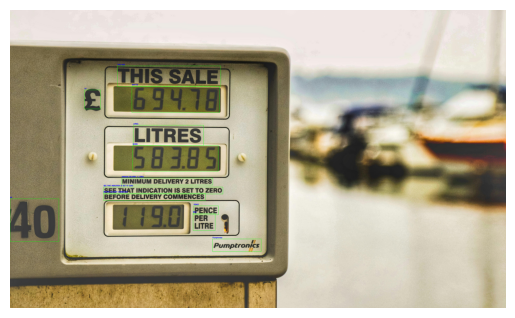

📦 Grouping OCR results...
✅ Grouped OCR results saved to: c:\Users\niteshk\Desktop\OCR\output2\grouped_text.csv
🎉 Processing complete!


In [3]:
import easyocr
import cv2
import csv
from matplotlib import pyplot as plt
import pandas as pd
import os

# === Paths ===
image_path = r"c:\Users\niteshk\Desktop\OCR\reader.jpg"
csv_output_path = r"c:\Users\niteshk\Desktop\OCR\output2\extracted_text.csv"
grouped_output_path = r"c:\Users\niteshk\Desktop\OCR\output2\grouped_text.csv"
annotated_image_path = r"c:\Users\niteshk\Desktop\OCR\output2\detected.jpg"

# === Step 1: OCR Extraction ===
print("🔍 Running OCR...")

reader = easyocr.Reader(['en'])
results = reader.readtext(image_path)

# Save OCR results to CSV
os.makedirs(os.path.dirname(csv_output_path), exist_ok=True)
with open(csv_output_path, mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(["Text", "Confidence", "Top_Left_X", "Top_Left_Y", "Bottom_Right_X", "Bottom_Right_Y"])
    for (bbox, text, confidence) in results:
        top_left = bbox[0]
        bottom_right = bbox[2]
        writer.writerow([text, f"{confidence:.2f}", top_left[0], top_left[1], bottom_right[0], bottom_right[1]])

print(f"✅ OCR results saved to: {csv_output_path}")

# === Step 2: Annotate and save detected image ===
image = cv2.imread(image_path)
for (bbox, text, confidence) in results:
    top_left = tuple(map(int, bbox[0]))
    bottom_right = tuple(map(int, bbox[2]))
    cv2.rectangle(image, top_left, bottom_right, (0, 255, 0), 2)
    cv2.putText(image, text, (top_left[0], top_left[1] - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

cv2.imwrite(annotated_image_path, image)
print(f"✅ Annotated image saved to: {annotated_image_path}")

# Optional display (comment out if running headless)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# === Step 3: Load OCR CSV and group text by parent-child boxes ===
print("📦 Grouping OCR results...")

# Define parent-child regions (X1, Y1, X2, Y2)
box_pairs = [
    {"parent": (1299, 687, 2549, 936), "child": (1474, 930, 2533, 1249)},
    {"parent": (1491, 1403, 2342, 1648), "child": (1483, 1647, 2519, 1959)}
]

df = pd.read_csv(csv_output_path)

required_cols = ["Text", "Top_Left_X", "Top_Left_Y", "Bottom_Right_X", "Bottom_Right_Y"]
if not all(col in df.columns for col in required_cols):
    raise ValueError("❌ Input CSV missing required columns: " + ", ".join(required_cols))

def box_in_region(bbox, region):
    x1, y1, x2, y2 = bbox
    rx1, ry1, rx2, ry2 = region
    # Check if any corner of bbox lies inside region
    return (rx1 <= x1 <= rx2 and ry1 <= y1 <= ry2) or (rx1 <= x2 <= rx2 and ry1 <= y2 <= ry2)

output_rows = []

for pair in box_pairs:
    parent_region = pair["parent"]
    child_region = pair["child"]

    parent_texts = df[df.apply(lambda row: box_in_region(
        (row["Top_Left_X"], row["Top_Left_Y"], row["Bottom_Right_X"], row["Bottom_Right_Y"]),
        parent_region
    ), axis=1)]["Text"].tolist()

    child_texts = df[df.apply(lambda row: box_in_region(
        (row["Top_Left_X"], row["Top_Left_Y"], row["Bottom_Right_X"], row["Bottom_Right_Y"]),
        child_region
    ), axis=1)]["Text"].tolist()

    output_rows.append({
        "Parent_Box": str(parent_region),
        "Parent_Texts": " ".join(parent_texts),
        "Child_Box": str(child_region),
        "Child_Texts": " ".join(child_texts)
    })

out_df = pd.DataFrame(output_rows)
out_df.to_csv(grouped_output_path, index=False, encoding='utf-8-sig')

print(f"✅ Grouped OCR results saved to: {grouped_output_path}")
print("🎉 Processing complete!")


In [1]:
#============> WORKING CODE FOR PETROL PUMP OCR AND DATA EXTRACTION WITH FORMATTED OUTPUT <==============#
#======================> WITH ROI BASED TEXT EXTRACTION <=======================#
#=====================> FINAL FORMATTED OUTPUT IN CSV <=======================#
#=======================> PASSING A IMAGE AND EXTRACTING DATA <=======================#

import easyocr
import cv2
import csv
import os
import pandas as pd
from matplotlib import pyplot as plt
from shapely.geometry import Polygon, Point
import re

# === Paths ===
image_path = r"c:\Users\niteshk\Desktop\OCR\reader.jpg"
csv_output_path = r"c:\Users\niteshk\Desktop\OCR\output4\extracted_text.csv"
grouped_output_path = r"c:\Users\niteshk\Desktop\OCR\output4\grouped_text.csv"
annotated_image_path = r"c:\Users\niteshk\Desktop\OCR\output4\detected.jpg"

# === Step 1: OCR Extraction ===
print("🔍 Running OCR...")

reader = easyocr.Reader(['en'])
results = reader.readtext(image_path)

# Save OCR results to CSV
os.makedirs(os.path.dirname(csv_output_path), exist_ok=True)
with open(csv_output_path, mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(["Text", "Confidence", "Top_Left_X", "Top_Left_Y", "Bottom_Right_X", "Bottom_Right_Y"])
    for (bbox, text, confidence) in results:
        top_left = bbox[0]
        bottom_right = bbox[2]
        writer.writerow([text, f"{confidence:.2f}", top_left[0], top_left[1], bottom_right[0], bottom_right[1]])

print(f"✅ OCR results saved to: {csv_output_path}")

# === Step 2: Annotate and save detected image ===
image = cv2.imread(image_path)
for (bbox, text, confidence) in results:
    top_left = tuple(map(int, bbox[0]))
    bottom_right = tuple(map(int, bbox[2]))
    cv2.rectangle(image, top_left, bottom_right, (0, 255, 0), 2)
    cv2.putText(image, text, (top_left[0], top_left[1] - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

cv2.imwrite(annotated_image_path, image)
print(f"✅ Annotated image saved to: {annotated_image_path}")

# === Step 3: ROI-based grouping ===
print("📦 Extracting text inside ROI regions...")

# Define ROI polygons
roi_polygons = [
    [(1240, 697), (2551, 690), (2557, 922), (1240, 918)],      # ROI 1
    [(1458, 1413), (2323, 1413), (2319, 1611), (1448, 1611)],  # ROI 2
    [(1458, 935), (2537, 938), (2541, 1238), (1461, 1245)],    # ROI 3
    [(1488, 1651), (2547, 1048), (2547, 1961), (1484, 1958)]   # ROI 4
]

df = pd.read_csv(csv_output_path)

# === Helper: Check if text bbox is inside ROI polygon ===
def is_inside_roi(bbox, polygon):
    x_center = (bbox[0] + bbox[2]) / 2
    y_center = (bbox[1] + bbox[3]) / 2
    point = Point(x_center, y_center)
    poly = Polygon(polygon)
    return poly.contains(point)

# === Group text by ROI ===
roi_texts = {f"ROI_{i+1}_Details": [] for i in range(len(roi_polygons))}

for _, row in df.iterrows():
    bbox = (row["Top_Left_X"], row["Top_Left_Y"], row["Bottom_Right_X"], row["Bottom_Right_Y"])
    text = str(row["Text"])
    for i, polygon in enumerate(roi_polygons):
        if is_inside_roi(bbox, polygon):
            roi_texts[f"ROI_{i+1}_Details"].append(text)
            break

# === Step 4: Post-processing numeric values ===
def fix_decimal(text):
    """Convert numbers like 694778 -> 694.78"""
    if re.fullmatch(r"\d{5,}", text):  # long numeric strings
        return f"{text[:-2]}.{text[-2:]}"
    return text

# Apply text cleaning and formatting
roi_texts = {k: [fix_decimal(t) for t in v] for k, v in roi_texts.items()}

# === Step 5: Build final formatted output ===
# Collect ROI groups safely
roi1 = roi_texts.get("ROI_1_Details", [])
roi2 = roi_texts.get("ROI_2_Details", [])
roi3 = roi_texts.get("ROI_3_Details", [])
roi4 = roi_texts.get("ROI_4_Details", [])

# Convert numeric strings to proper floats if possible
def to_float(val):
    try:
        return float(val)
    except:
        return val
    
num1 = to_float(roi3[0]) if roi3 else ""
num2 = to_float(roi4[0]) if roi4 else ""

# headers = [roi_texts["ROI_1_Details"], roi_texts["ROI_2_Details"]]
# values = [roi_texts["ROI_3_Details"], roi_texts["ROI_4_Details"]]

final_data = {
    (roi1[0] if roi1 else ""): num1,
    (roi2[0] if roi2 else ""): num2
}

# final_data = {
#     headers[0][0] if headers[0] else "": headers[1][0] if headers[1] else "",
#     values[0][0] if values[0] else "": values[1][0] if values[1] else "",
# }

# Create DataFrame in the desired layout
final_df = pd.DataFrame([final_data])
print("final_df:", final_df)
final_df.to_csv(grouped_output_path, index=False, encoding='utf-8-sig')

print(f"✅ Final formatted result saved to: {grouped_output_path}")
print("🎉 Done! Output ready.")


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


🔍 Running OCR...


c:\Users\niteshk\anaconda3\envs\myenv1\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


✅ OCR results saved to: c:\Users\niteshk\Desktop\OCR\output4\extracted_text.csv
✅ Annotated image saved to: c:\Users\niteshk\Desktop\OCR\output4\detected.jpg
📦 Extracting text inside ROI regions...
final_df:    THIS SALE  LITRES
0    6947.78  583.85
✅ Final formatted result saved to: c:\Users\niteshk\Desktop\OCR\output4\grouped_text.csv
🎉 Done! Output ready.


In [ ]:
#!/usr/bin/env python3
"""
ocr_pipeline.py
Merged OCR + ROI grouping pipeline with video support.

Features:
- EasyOCR text extraction for images and videos.
- ROI grouping: either from JSON (polygons) or auto-generated grid (n-rois).
- Saves:
  - per-frame raw OCR CSV
  - per-frame annotated image
  - per-frame grouped CSV (ROI-wise)
  - combined grouped CSV for the run
- CLI args: input path, mode (image/video), out dir, languages, n-rois, rois-file, frame-skip.

Dependencies:
- easyocr
- opencv-python (cv2)
- pandas
- shapely
- numpy
- matplotlib (optional only for debug/visual)
"""

import os
import sys
import argparse
import csv
import json
import re
from datetime import datetime
from pathlib import Path
from typing import List, Tuple, Dict, Any

import cv2
import numpy as np
import pandas as pd
import easyocr
from shapely.geometry import Polygon, Point

# ---------------------------
# Helpers
# ---------------------------

def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def now_str():
    return datetime.now().strftime("%Y%m%d_%H%M%S")

# ---------------------------
# ROI utilities
# ---------------------------

def load_rois_from_json(json_path: str) -> List[List[Tuple[int, int]]]:
    """
    JSON format expected:
    {
      "rois": {
         "ROI_1": [[x1,y1],[x2,y2],[x3,y3],[x4,y4]],
         "ROI_2": [...]
      }
    }
    Returns list of polygons (list of (x,y) tuples) in order.
    """
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    rois = []
    if isinstance(data, dict):
        # Accept top-level "rois" or direct mapping
        mapping = data.get("rois", data)
        for key in sorted(mapping.keys()):
            poly = mapping[key]
            rois.append([tuple(map(int, p)) for p in poly])
    elif isinstance(data, list):
        for poly in data:
            rois.append([tuple(map(int, p)) for p in poly])
    return rois

def make_grid_rois(image_w: int, image_h: int, n_rois: int) -> List[List[Tuple[int,int]]]:
    """
    Create n_rois polygons by splitting image into rows x cols grid roughly square.
    Returns list of polygon point lists.
    """
    if n_rois <= 0:
        return []
    # choose grid dims close to sqrt
    cols = int(np.ceil(np.sqrt(n_rois)))
    rows = int(np.ceil(n_rois / cols))
    cell_w = image_w // cols
    cell_h = image_h // rows
    rois = []
    count = 0
    for r in range(rows):
        for c in range(cols):
            if count >= n_rois:
                break
            x1 = c * cell_w
            y1 = r * cell_h
            # last column/row take remainder
            x2 = (c + 1) * cell_w if c < cols - 1 else image_w
            y2 = (r + 1) * cell_h if r < rows - 1 else image_h
            poly = [(x1, y1), (x2, y1), (x2, y2), (x1, y2)]
            rois.append(poly)
            count += 1
    return rois

def is_inside_roi(bbox: Tuple[float,float,float,float], polygon_pts: List[Tuple[int,int]]) -> bool:
    """
    bbox: (x1,y1,x2,y2) - center point used for membership
    polygon_pts: list of (x,y)
    """
    x_center = (bbox[0] + bbox[2]) / 2.0
    y_center = (bbox[1] + bbox[3]) / 2.0
    point = Point(x_center, y_center)
    poly = Polygon(polygon_pts)
    return poly.contains(point)

# ---------------------------
# OCR and processing
# ---------------------------

def fix_decimal(text: str) -> str:
    """Convert long digits like 694778 -> 694.78 (same heuristic you used)."""
    t = text.strip()
    # remove commas commonly introduced by OCR (like 1,234 -> 1234)
    t = t.replace(',', '')
    if re.fullmatch(r"\d{5,}", t):
        return f"{t[:-2]}.{t[-2:]}"
    return t

def to_float_if_possible(val):
    try:
        return float(val)
    except Exception:
        return val

def run_easyocr_on_image(reader: easyocr.Reader, image: np.ndarray) -> List[Tuple[List[List[float]], str, float]]:
    """
    Returns the raw results: list of (bbox, text, confidence)
    bbox is list of four points: [[x1,y1],[x2,y2],[x3,y3],[x4,y4]]
    """
    # EasyOCR expects RGB
    if image.shape[2] == 3:
        img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    else:
        img_rgb = image
    results = reader.readtext(img_rgb)  # returns list (bbox, text, confidence)
    return results

# ---------------------------
# Output helpers
# ---------------------------

def save_raw_csv(csv_path: str, results):
    """
    results: list of (bbox, text, confidence)
    bbox: list of 4 points, we store top-left and bottom-right.
    """
    with open(csv_path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(["Text", "Confidence", "Top_Left_X", "Top_Left_Y", "Bottom_Right_X", "Bottom_Right_Y"])
        for bbox, text, conf in results:
            top_left = bbox[0]
            bottom_right = bbox[2]
            writer.writerow([text, f"{conf:.3f}", int(top_left[0]), int(top_left[1]), int(bottom_right[0]), int(bottom_right[1])])

def annotate_image_and_save(save_path: str, image: np.ndarray, results, rois: List[List[Tuple[int,int]]]=None):
    img = image.copy()
    # draw OCR bboxes & text
    for bbox, text, conf in results:
        tl = tuple(map(int, bbox[0]))
        br = tuple(map(int, bbox[2]))
        cv2.rectangle(img, tl, br, (0,255,0), 2)
        cv2.putText(img, text, (tl[0], max(10, tl[1]-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)
    # draw ROIs
    if rois:
        for idx, poly in enumerate(rois):
            pts = np.array(poly, dtype=np.int32).reshape((-1,1,2))
            cv2.polylines(img, [pts], True, (0,0,255), 2)
            # label
            cx = int(sum([p[0] for p in poly]) / len(poly))
            cy = int(sum([p[1] for p in poly]) / len(poly))
            cv2.putText(img, f"ROI_{idx+1}", (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)
    cv2.imwrite(save_path, img)

def group_texts_by_rois(results, rois: List[List[Tuple[int,int]]]):
    """
    results: raw OCR results
    rois: list of polygons
    Returns dict: roi_label -> list of texts
    """
    grouped = {f"ROI_{i+1}_Details": [] for i in range(len(rois))}
    for bbox, text, conf in results:
        tl = bbox[0]
        br = bbox[2]
        bbox_xy = (tl[0], tl[1], br[0], br[1])
        for i, poly in enumerate(rois):
            if is_inside_roi(bbox_xy, poly):
                grouped[f"ROI_{i+1}_Details"].append(text)
                break
    # apply decimal fix
    for k,v in grouped.items():
        grouped[k] = [fix_decimal(t) for t in v]
    return grouped

# ---------------------------
# High-level image/frame pipeline
# ---------------------------

def process_single_image(
    reader,
    image_path: str,
    out_dir: str,
    rois: List[List[Tuple[int,int]]]=None,
    auto_n_rois: int = 0,
    prefix: str = None
) -> Dict[str, Any]:
    """
    Process one image and produce outputs.
    Returns a dict with metadata and grouped results for aggregation.
    """
    image = cv2.imread(image_path)
    if image is None:
        raise RuntimeError(f"Could not read image: {image_path}")

    h, w = image.shape[:2]
    # if rois not provided and auto generation requested
    if (not rois) and auto_n_rois > 0:
        rois = make_grid_rois(w, h, auto_n_rois)

    results = run_easyocr_on_image(reader, image)
    # outputs
    base_name = prefix if prefix else Path(image_path).stem
    raw_csv = os.path.join(out_dir, f"{base_name}_raw_{now_str()}.csv")
    save_raw_csv(raw_csv, results)

    annotated_path = os.path.join(out_dir, f"{base_name}_annotated_{now_str()}.jpg")
    annotate_image_and_save(annotated_path, image, results, rois)

    grouped = {}
    if rois:
        grouped = group_texts_by_rois(results, rois)
        # produce a grouped csv
        grouped_csv = os.path.join(out_dir, f"{base_name}_grouped_{now_str()}.csv")
        # create rows as single row mapping roi->joined text
        row = {k: " | ".join(v) if isinstance(v,list) else v for k,v in grouped.items()}
        df = pd.DataFrame([row])
        df.to_csv(grouped_csv, index=False, encoding='utf-8-sig')
    else:
        grouped = {}

    return {
        "image_path": image_path,
        "annotated_path": annotated_path,
        "raw_csv": raw_csv,
        "grouped": grouped
    }

# ---------------------------
# Video pipeline
# ---------------------------

def process_video(
    reader,
    video_path: str,
    out_dir: str,
    rois: List[List[Tuple[int,int]]]=None,
    auto_n_rois: int = 0,
    frame_skip: int = 0,
    max_frames: int = None
) -> List[Dict[str, Any]]:
    """
    Walk through video frames and run the same pipeline on frames.
    frame_skip: skip N frames between processed frames (0 => process every frame)
    max_frames: limit to N processed frames (None => all)
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Failed to open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS) or 0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    print(f"[VIDEO] {video_path} | fps={fps:.2f} | total_frames={total_frames}")

    outputs = []
    frame_idx = 0
    processed = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        # decide whether to process this frame
        if frame_idx % (frame_skip + 1) != 0:
            frame_idx += 1
            continue

        # If rois not provided and auto_n_rois requested, generate based on frame shape
        h, w = frame.shape[:2]
        if (not rois) and auto_n_rois > 0:
            cur_rois = make_grid_rois(w, h, auto_n_rois)
        else:
            cur_rois = rois

        # save the frame to a temp image in out_dir and re-use process_single_image for uniform outputs
        frame_name = f"{Path(video_path).stem}_frame{frame_idx}_{now_str()}.jpg"
        frame_path = os.path.join(out_dir, frame_name)
        cv2.imwrite(frame_path, frame)

        meta = process_single_image(reader, frame_path, out_dir, rois=cur_rois, auto_n_rois=0, prefix=Path(frame_name).stem)
        meta["frame_index"] = frame_idx
        outputs.append(meta)

        processed += 1
        frame_idx += 1

        if max_frames and processed >= max_frames:
            break

    cap.release()
    return outputs

# ---------------------------
# CLI & main
# ---------------------------

def parse_args():
    p = argparse.ArgumentParser(description="OCR pipeline (image/video) with ROI grouping.")
    p.add_argument("input", help="Path to image or video")
    p.add_argument("--mode", choices=["image","video"], default="image", help="Process as image or video")
    p.add_argument("--out", default="./results", help="Output directory")
    p.add_argument("--langs", default="en", help="Comma-separated languages for EasyOCR (e.g. en,hi)")
    p.add_argument("--n-rois", type=int, default=4, help="Auto-generate N ROIs as grid if --rois-file not provided")
    p.add_argument("--rois-file", default=None, help="Optional JSON file with ROI polygons")
    p.add_argument("--frame-skip", type=int, default=0, help="For video: skip N frames between processed frames (0=process all)")
    p.add_argument("--max-frames", type=int, default=None, help="For video: limit number of processed frames")
    p.add_argument("--verbose", action="store_true")
    p.add_argument("--gpu", action="store_true", help="Let EasyOCR know whether to use GPU if available")
    return p.parse_args()

def main():
    args = parse_args()
    input_path = args.input
    out_dir = args.out
    ensure_dir(out_dir)

    langs = [l.strip() for l in args.langs.split(",") if l.strip()]
    use_gpu = args.gpu

    print(f"[CONFIG] input={input_path} mode={args.mode} out={out_dir} langs={langs} n_rois={args.n_rois} rois_file={args.rois_file}")

    # initialize EasyOCR reader (slow at first call)
    reader = easyocr.Reader(langs, gpu=use_gpu)

    # load rois if provided
    rois = None
    if args.rois_file:
        rois = load_rois_from_json(args.rois_file)
        print(f"[ROIS] Loaded {len(rois)} polygons from {args.rois_file}")

    aggregated_rows = []

    if args.mode == "image":
        res = process_single_image(reader, input_path, out_dir, rois=rois, auto_n_rois=args.n_rois)
        print("[DONE] Image processed.")
        # Save grouped if present
        if res.get("grouped"):
            # convert grouped dict to flat row
            row = {"source": input_path}
            for k,v in res["grouped"].items():
                row[k] = " | ".join(v) if isinstance(v, list) else v
            aggregated_rows.append(row)

    else:  # video
        outputs = process_video(reader, input_path, out_dir, rois=rois, auto_n_rois=args.n_rois, frame_skip=args.frame_skip, max_frames=args.max_frames)
        print(f"[DONE] Video processed: {len(outputs)} frames processed.")
        for out in outputs:
            row = {"source": f"{out.get('image_path')} (frame:{out.get('frame_index')})"}
            grouped = out.get("grouped", {})
            for k,v in grouped.items():
                row[k] = " | ".join(v) if isinstance(v, list) else v
            aggregated_rows.append(row)

    # write combined CSV if we have aggregated rows
    if aggregated_rows:
        combined_csv = os.path.join(out_dir, f"combined_grouped_{now_str()}.csv")
        df = pd.DataFrame(aggregated_rows)
        df.to_csv(combined_csv, index=False, encoding='utf-8-sig')
        print(f"[AGGREGATED] Combined grouped CSV saved to: {combined_csv}")

    print("All done.")

if __name__ == "__main__":
    main()


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


🔍 Running OCR...


c:\Users\niteshk\anaconda3\envs\myenv1\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


✅ OCR results saved to: c:\Users\niteshk\Desktop\OCR\output6\extracted_text.csv
🧩 Detecting ROIs automatically...
✅ Available ROIs in roi_texts: ['ROI_1_Details']

📋 Final OCR Result:
Header 1 (ROI 1): 6947.78
✅ Final formatted result saved to: c:\Users\niteshk\Desktop\OCR\output6\grouped_text.csv
🎉 Done! ROIs detected automatically.
